In [23]:
import pandas as pd
import random

In [24]:
import os, sys
import constants_biology, constants_labels, constants_training

In [25]:
df = pd.read_csv('../../../data/CoV-AbDab_080224.csv')

In [ ]:
def generate_hard_negatives(df, target_count, binding_col=constants_labels.BINDING_YES, neutral_col=constants_labels.NEUTRAL_YES):
    """
    Creates decoy negatives by shuffling CDR loops. 
    Maintains 'ND' and NaN values to preserve Nanobody vs Antibody logic.
    """
    
    # Sample from existing binders (Class 1) to ensure realistic scaffolds
    positives = df[df[binding_col] == constants_labels.TARGET].sample(n=target_count, replace=True if target_count > len(df) else False)
    negatives = positives.copy()

    def safe_shuffle(seq):
        # Return as is if it's ND, NaN, or too short to shuffle meaningfully
        if pd.isna(seq) or str(seq).upper() == 'ND' or len(str(seq)) < 2:
            return seq
        
        # Convert to list, shuffle, and rejoin
        char_list = list(str(seq))
        random.shuffle(char_list)
        return "".join(char_list)

    # Apply shuffling only to the CDR loops
    # Shuffling the 'fingers' but keeping the Framework intact
    negatives['CDRH3'] = negatives['CDRH3'].apply(safe_shuffle)
    
    if 'CDRL3' in negatives.columns:
        negatives['CDRL3'] = negatives['CDRL3'].apply(safe_shuffle)

    # Mark as non-binding and non-neutralizing
    negatives[constants_labels.BINDING_NOT] = constants_labels.TARGET
    negatives[constants_labels.NEUTRAL_NOT] = constants_labels.TARGET
    negatives[binding_col] = None
    negatives[neutral_col] = None
    
    # Optional: Tag them to keep track them in EDA
    negatives['data_source'] = 'synthetic_negative'
    
    return negatives


# df_synthetic = generate_hard_negatives(df, target_count=5000)

# Combine with original data
# df_balanced = pd.concat([df, df_synthetic], axis=0).reset_index(drop=True)
df_balanced = df.copy()  # Use original data for EDA

In [27]:
df_balanced.to_csv("./data/raw_transformation_00.csv")

In [28]:
import pandas as pd
import numpy as np
import logomaker
import matplotlib.pyplot as plt

def plot_cdr_logo(sequences, title="CDRH3 Sequence Logo"):
    # 1. Filter out invalid characters and ensure sequences aren't empty
    # We only want the standard 20 Amino Acids
    valid_aa = list('ACDEFGHIKLMNPQRSTVWY')
    
    # Standardize length
    max_len = int(np.percentile([len(s) for s in sequences], 75))
    aligned_seqs = [s.ljust(max_len, 'A')[:max_len] for s in sequences if len(s) >= 5] 
    # Note: I changed '-' padding to 'A' temporarily because logomaker 
    # sometimes crashes on non-AA characters in certain matplotlib versions.

    # 2. Generate matrix
    counts_df = logomaker.alignment_to_matrix(aligned_seqs)
    
    # 3. Filter the columns to ONLY valid Amino Acids 
    # (This prevents the AttributeError by removing gap characters)
    counts_df = counts_df[counts_df.columns.intersection(valid_aa)]
    
    # 4. Transform to information content
    info_df = logomaker.transform_matrix(counts_df, from_type='counts', to_type='information')
    
    # 5. Plot with a fallback for the matplotlib error
    fig, ax = plt.subplots(figsize=(12, 4))
    try:
        logo = logomaker.Logo(info_df, ax=ax, color_scheme='weblogo_protein')
        ax.set_title(title)
    except AttributeError:
        # Fallback: If it still fails, the environment needs a matplotlib downgrade
        print("Matplotlib version mismatch detected. Try: pip install matplotlib==3.8.4")
    
    plt.show()

In [29]:
%run "01_label_processor.ipynb"

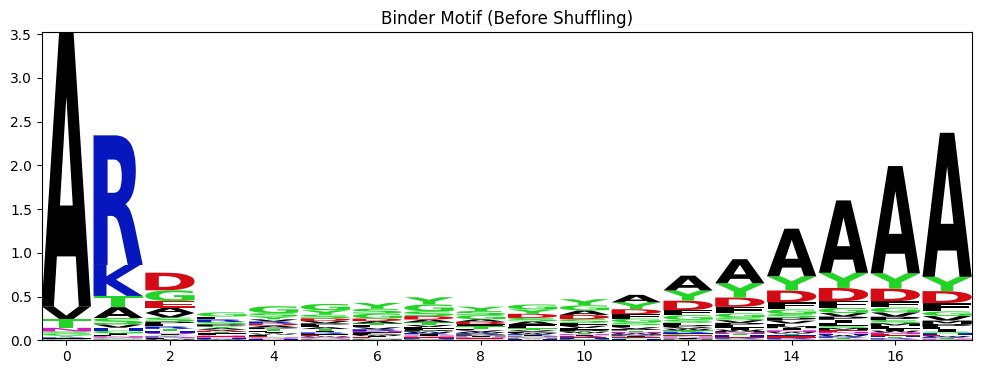

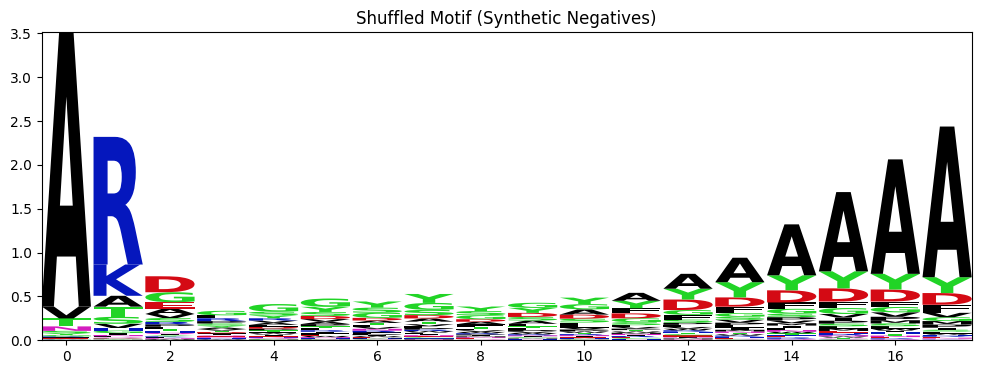

In [30]:
# Usage:
df = pd.concat([pd.read_csv('./data/01_binding_labels.csv'), df_balanced], axis=1)
binders = df[df['is_binding_SARS-CoV2_WT'] == 1]['CDRH3']
plot_cdr_logo(binders, title="Binder Motif (Before Shuffling)")

shuffled = df_synthetic['CDRH3']
plot_cdr_logo(shuffled, title="Shuffled Motif (Synthetic Negatives)")

In [31]:
%run "02_naive_processor.ipynb"

<class 'pandas.core.frame.DataFrame'>
Index: 17918 entries, 0 to 17917
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Unnamed: 0           17918 non-null  int64 
 1   Name                 17918 non-null  object
 2   Ab or Nb             17918 non-null  object
 3   Binds to             12918 non-null  object
 4   Doesn't Bind to      8201 non-null   object
 5   Neutralising Vs      6373 non-null   object
 6   Not Neutralising Vs  10482 non-null  object
 7   Protein + Epitope    17912 non-null  object
 8   Origin               17910 non-null  object
 9   VHorVHH              17918 non-null  object
 10  VL                   16715 non-null  object
 11  Heavy V Gene         17918 non-null  object
 12  Heavy J Gene         17918 non-null  object
 13  Light V Gene         16715 non-null  object
 14  Light J Gene         16715 non-null  object
 15  CDRH3                17918 non-null  object
 16  CDRL3    

In [32]:
%run "03_motif_processor.ipynb"

In [ ]:
%run "04_biochemical_processor.ipynb"